<html>
<h1> <b>Dự đoán bệnh tiểu đường bằng Pyspark </html> </b></h1>

In [ ]:
!apt-get install openjdk-8-jdk-headless -qq > /dev/null


In [ ]:
!wget -q https://archive.apache.org/dist/spark/spark-3.1.2/spark-3.1.2-bin-hadoop3.2.tgz
!tar xf spark-3.1.2-bin-hadoop3.2.tgz
!pip install -q findspark

In [ ]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.1.2-bin-hadoop2.7"


In [ ]:
import findspark
findspark.init("/content/spark-3.1.2-bin-hadoop3.2")

In [ ]:
!pip install pyspark

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.3/317.3 MB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyspark: filename=pyspark-3.5.2-py2.py3-none-any.whl size=317812365 sha256=34c8b940f05fea1a9ac4f0a4149a338073069c9f424a32a0b5d77effbdc83cfe
  Stored in directory: /root/.cache/pip/wheels/34/34/bd/03944534c44b677cd5859f248090daa9fb27b3c8f8e5f49574
Successfully built pyspark


In [ ]:
from pyspark.ml.stat import Correlation
from pyspark.sql import SparkSession
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.sql.functions import col, count, when, isnull, isnan
from pyspark.ml import pipeline
spark = SparkSession.builder.appName("spark").getOrCreate()
spark


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
df = spark.read.csv("/content/drive/MyDrive/Big_Data/diabetes_prediction_dataset.csv", header=True, inferSchema=True)
df.show(10)

+------+----+------------+-------------+---------------+-----+-----------+-------------------+--------+
|gender| age|hypertension|heart_disease|smoking_history|  bmi|HbA1c_level|blood_glucose_level|diabetes|
+------+----+------------+-------------+---------------+-----+-----------+-------------------+--------+
|Female|80.0|           0|            1|          never|25.19|        6.6|                140|       0|
|Female|54.0|           0|            0|        No Info|27.32|        6.6|                 80|       0|
|  Male|28.0|           0|            0|          never|27.32|        5.7|                158|       0|
|Female|36.0|           0|            0|        current|23.45|        5.0|                155|       0|
|  Male|76.0|           1|            1|        current|20.14|        4.8|                155|       0|
|Female|20.0|           0|            0|          never|27.32|        6.6|                 85|       0|
|Female|44.0|           0|            0|          never|19.31|  

In [ ]:
df.printSchema()

root
 |-- gender: string (nullable = true)
 |-- age: double (nullable = true)
 |-- hypertension: integer (nullable = true)
 |-- heart_disease: integer (nullable = true)
 |-- smoking_history: string (nullable = true)
 |-- bmi: double (nullable = true)
 |-- HbA1c_level: double (nullable = true)
 |-- blood_glucose_level: integer (nullable = true)
 |-- diabetes: integer (nullable = true)



In [ ]:
# Kiểm tra dữ liệu thiếu
df.select([count(when(isnull(c), c)).alias(c) for c in df.columns]).show()

+------+---+------------+-------------+---------------+---+-----------+-------------------+--------+
|gender|age|hypertension|heart_disease|smoking_history|bmi|HbA1c_level|blood_glucose_level|diabetes|
+------+---+------------+-------------+---------------+---+-----------+-------------------+--------+
|     0|  0|           0|            0|              0|  0|          0|                  0|       0|
+------+---+------------+-------------+---------------+---+-----------+-------------------+--------+



In [ ]:
num_rows = df.count()
num_columns = len(df.columns)

print(f"Số hàng: {num_rows}, Số cột: {num_columns}")

Số hàng: 100000, Số cột: 9


In [ ]:
df.columns

['gender',
 'age',
 'hypertension',
 'heart_disease',
 'smoking_history',
 'bmi',
 'HbA1c_level',
 'blood_glucose_level',
 'diabetes']

In [ ]:
null_counts = {col: df.filter(df[col].isNull()).count() for col in df.columns}

for col, count in null_counts.items():
    print(f"Column '{col}' has {count} null values")

Column 'gender' has 0 null values
Column 'age' has 0 null values
Column 'hypertension' has 0 null values
Column 'heart_disease' has 0 null values
Column 'smoking_history' has 0 null values
Column 'bmi' has 0 null values
Column 'HbA1c_level' has 0 null values
Column 'blood_glucose_level' has 0 null values
Column 'diabetes' has 0 null values


In [ ]:
df.describe().show()

+-------+------+-----------------+------------------+------------------+---------------+-----------------+------------------+-------------------+-------------------+
|summary|gender|              age|      hypertension|     heart_disease|smoking_history|              bmi|       HbA1c_level|blood_glucose_level|           diabetes|
+-------+------+-----------------+------------------+------------------+---------------+-----------------+------------------+-------------------+-------------------+
|  count|100000|           100000|            100000|            100000|         100000|           100000|            100000|             100000|             100000|
|   mean|  null|41.88585600000013|           0.07485|           0.03942|           null|27.32076709999422|5.5275069999983275|          138.05806|              0.085|
| stddev|  null|22.51683987161704|0.2631504702289171|0.1945930169980986|           null|6.636783416648357|1.0706720918835468|  40.70813604870383|0.27888308976661896|
|   

+------+--------+-----+
|gender|diabetes|count|
+------+--------+-----+
|  Male|       1| 4039|
| Other|       0|   18|
|Female|       0|54091|
|  Male|       0|37391|
|Female|       1| 4461|
+------+--------+-----+

+---------------+--------+-----+
|smoking_history|diabetes|count|
+---------------+--------+-----+
|           ever|       0| 3532|
|         former|       1| 1590|
|          never|       0|31749|
|        current|       0| 8338|
|        No Info|       1| 1454|
|           ever|       1|  472|
|    not current|       0| 5757|
|    not current|       1|  690|
|        No Info|       0|34362|
|         former|       0| 7762|
|        current|       1|  948|
|          never|       1| 3346|
+---------------+--------+-----+



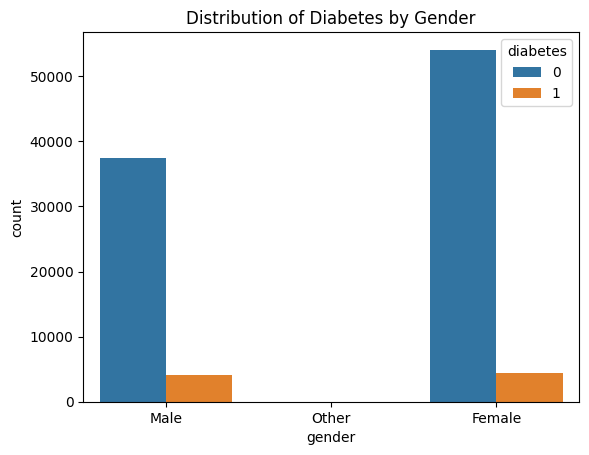

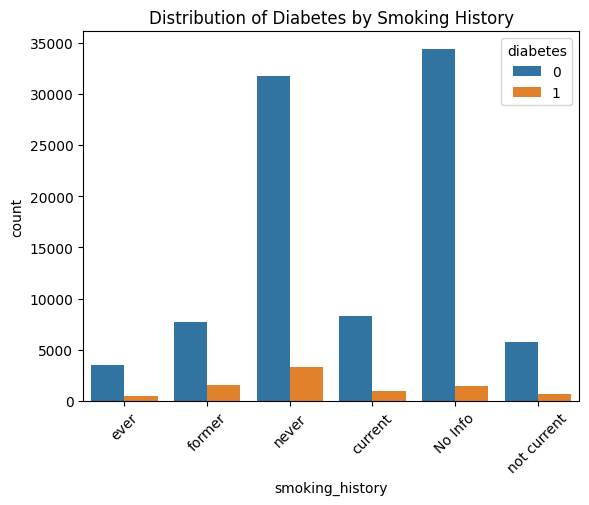

In [ ]:
# Kiểm tra sự phân phối của 'gender' theo 'diabetes'
df.groupBy("gender", "diabetes").count().show()

# Kiểm tra sự phân phối của 'smoking_history' theo 'diabetes'
df.groupBy("smoking_history", "diabetes").count().show()

# Vẽ biểu đồ
sns.barplot(x="gender", y="count", hue="diabetes", data=df.groupBy("gender", "diabetes").count().toPandas())
plt.title("Distribution of Diabetes by Gender")
plt.show()

sns.barplot(x="smoking_history", y="count", hue="diabetes", data=df.groupBy("smoking_history", "diabetes").count().toPandas())
plt.title("Distribution of Diabetes by Smoking History")
plt.xticks(rotation=45)
plt.show()

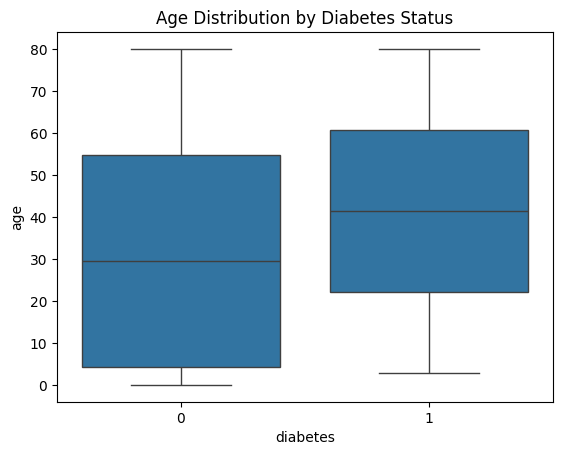

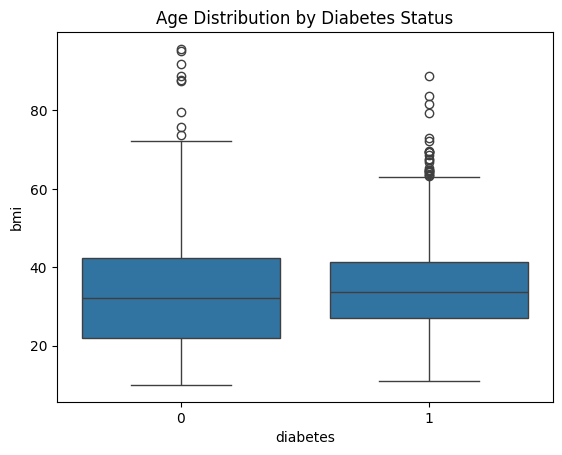

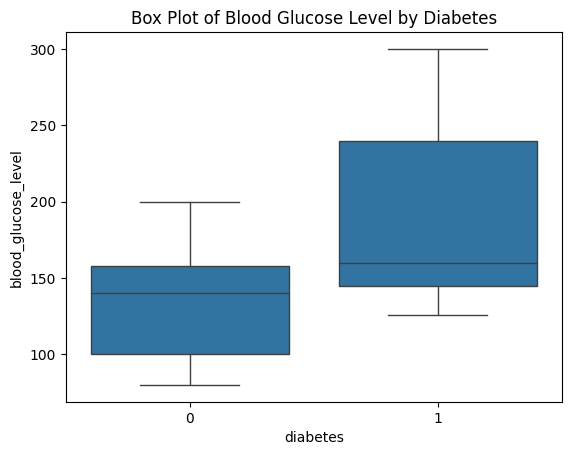

In [ ]:
# Vẽ biểu đồ boxplot
pandas_df = df.toPandas()
sns.boxplot(x="diabetes", y="age", data= df.groupBy("age", "diabetes").count().toPandas())
plt.title("Age Distribution by Diabetes Status")
plt.show()

 # Vẽ biểu đồ boxplot
sns.boxplot(x="diabetes", y="bmi", data=df.groupBy("bmi", "diabetes").count().toPandas())
plt.title("Age Distribution by Diabetes Status")
plt.show()

sns.boxplot(data=pandas_df, x='diabetes', y='blood_glucose_level')
plt.title('Box Plot of Blood Glucose Level by Diabetes')
plt.show()


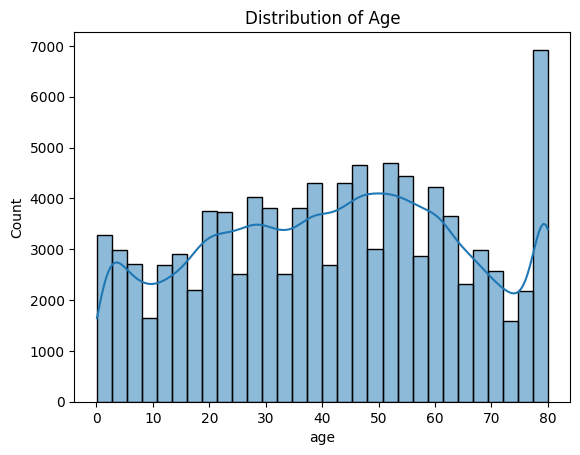

In [ ]:
# Lấy cột 'age' dưới dạng Pandas Series
age_series = pandas_df['age']

# Hiển thị phân phối của cột 'age'
sns.histplot(age_series, kde=True, bins=30)
plt.title('Distribution of Age')
plt.show()


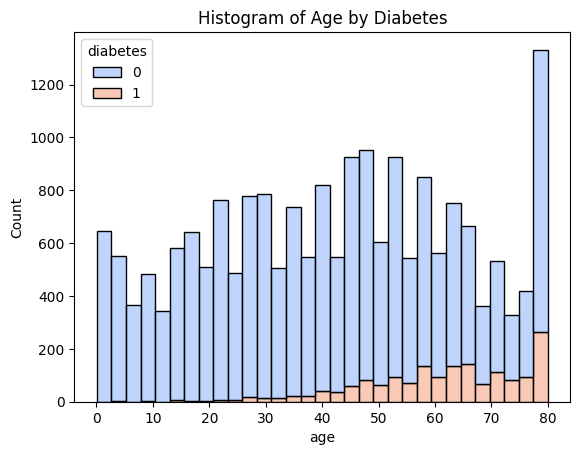

In [ ]:
sns.histplot(data=pandas_df, x='age', hue='diabetes', multiple='stack', palette='coolwarm')
plt.title('Histogram of Age by Diabetes')
plt.show()


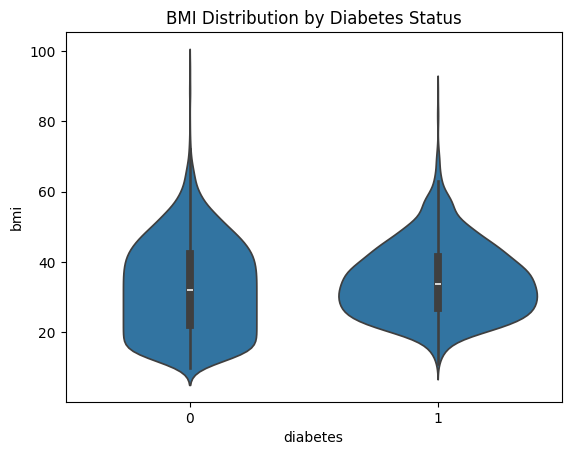

In [ ]:
# Vẽ biểu đồ violin
sns.violinplot(x="diabetes", y="bmi", data=df.groupBy("bmi", "diabetes").count().toPandas())
plt.title("BMI Distribution by Diabetes Status")
plt.show()

<ipython-input-61-7919796949b3>:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=pandas_df, x='diabetes', y='bmi', ci=None, palette='coolwarm')
<ipython-input-61-7919796949b3>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pandas_df, x='diabetes', y='bmi', ci=None, palette='coolwarm')


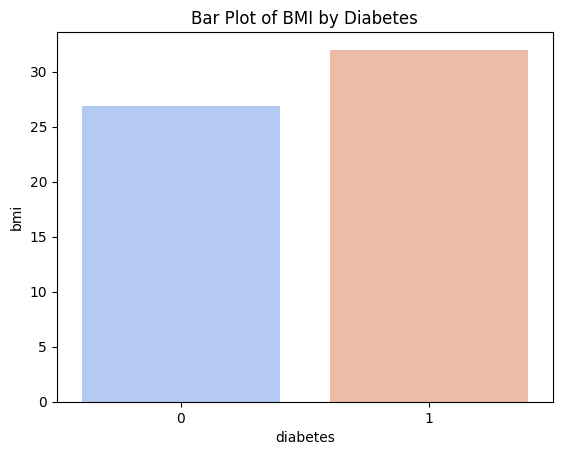

In [ ]:
sns.barplot(data=pandas_df, x='diabetes', y='bmi', ci=None, palette='coolwarm')
plt.title('Bar Plot of BMI by Diabetes')
plt.show()

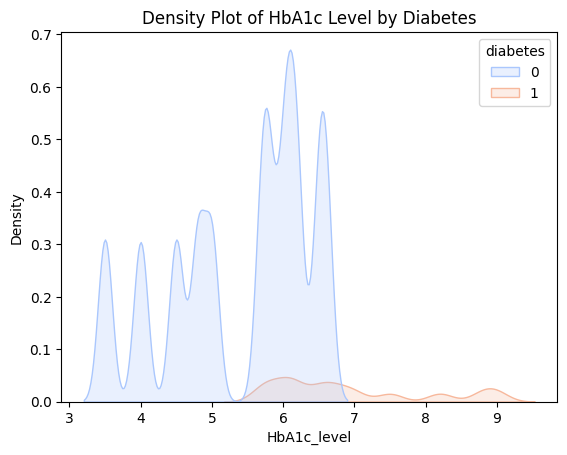

In [ ]:
sns.kdeplot(data=pandas_df, x='HbA1c_level', hue='diabetes', fill=True, palette='coolwarm')
plt.title('Density Plot of HbA1c Level by Diabetes')
plt.show()


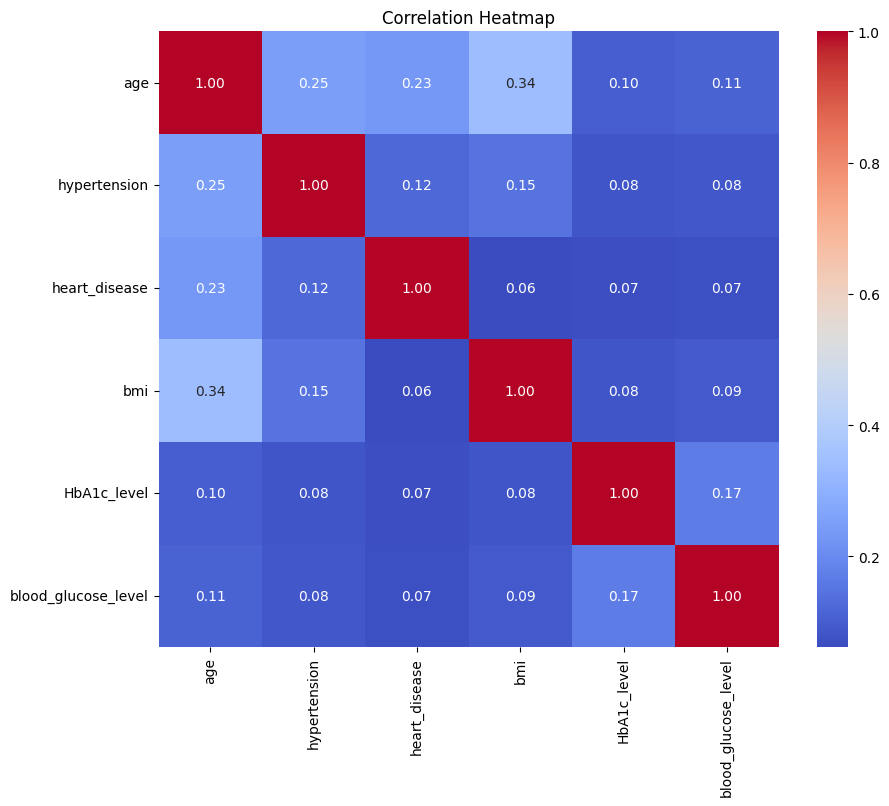

In [ ]:
# Bước 1: Chuyển đổi PySpark DataFrame thành Pandas DataFrame
pandas_df = df.toPandas()

# Bước 2: Lọc các cột số
numeric_df = pandas_df[['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']]

# Bước 3: Tạo heatmap cho các cột đã chọn
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title('Correlation Heatmap')
plt.show()


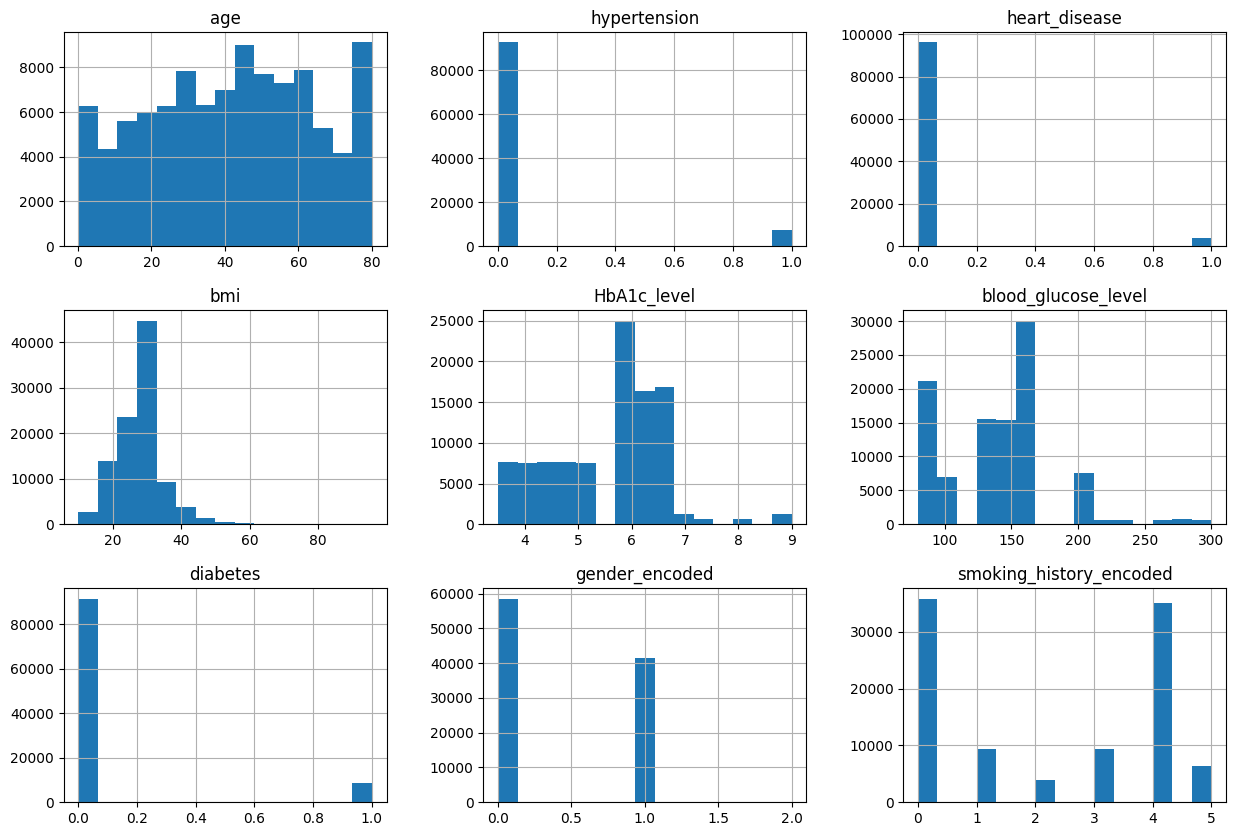

In [ ]:
pandas_df = df.toPandas()

pandas_df['gender_encoded'] = pd.Categorical(pandas_df['gender']).codes
pandas_df['smoking_history_encoded'] = pd.Categorical(pandas_df['smoking_history']).codes


# Vẽ biểu đồ histogram bằng Pandas
pandas_df.hist(bins=15, figsize=(15, 10), layout=(3, 3))
plt.show()


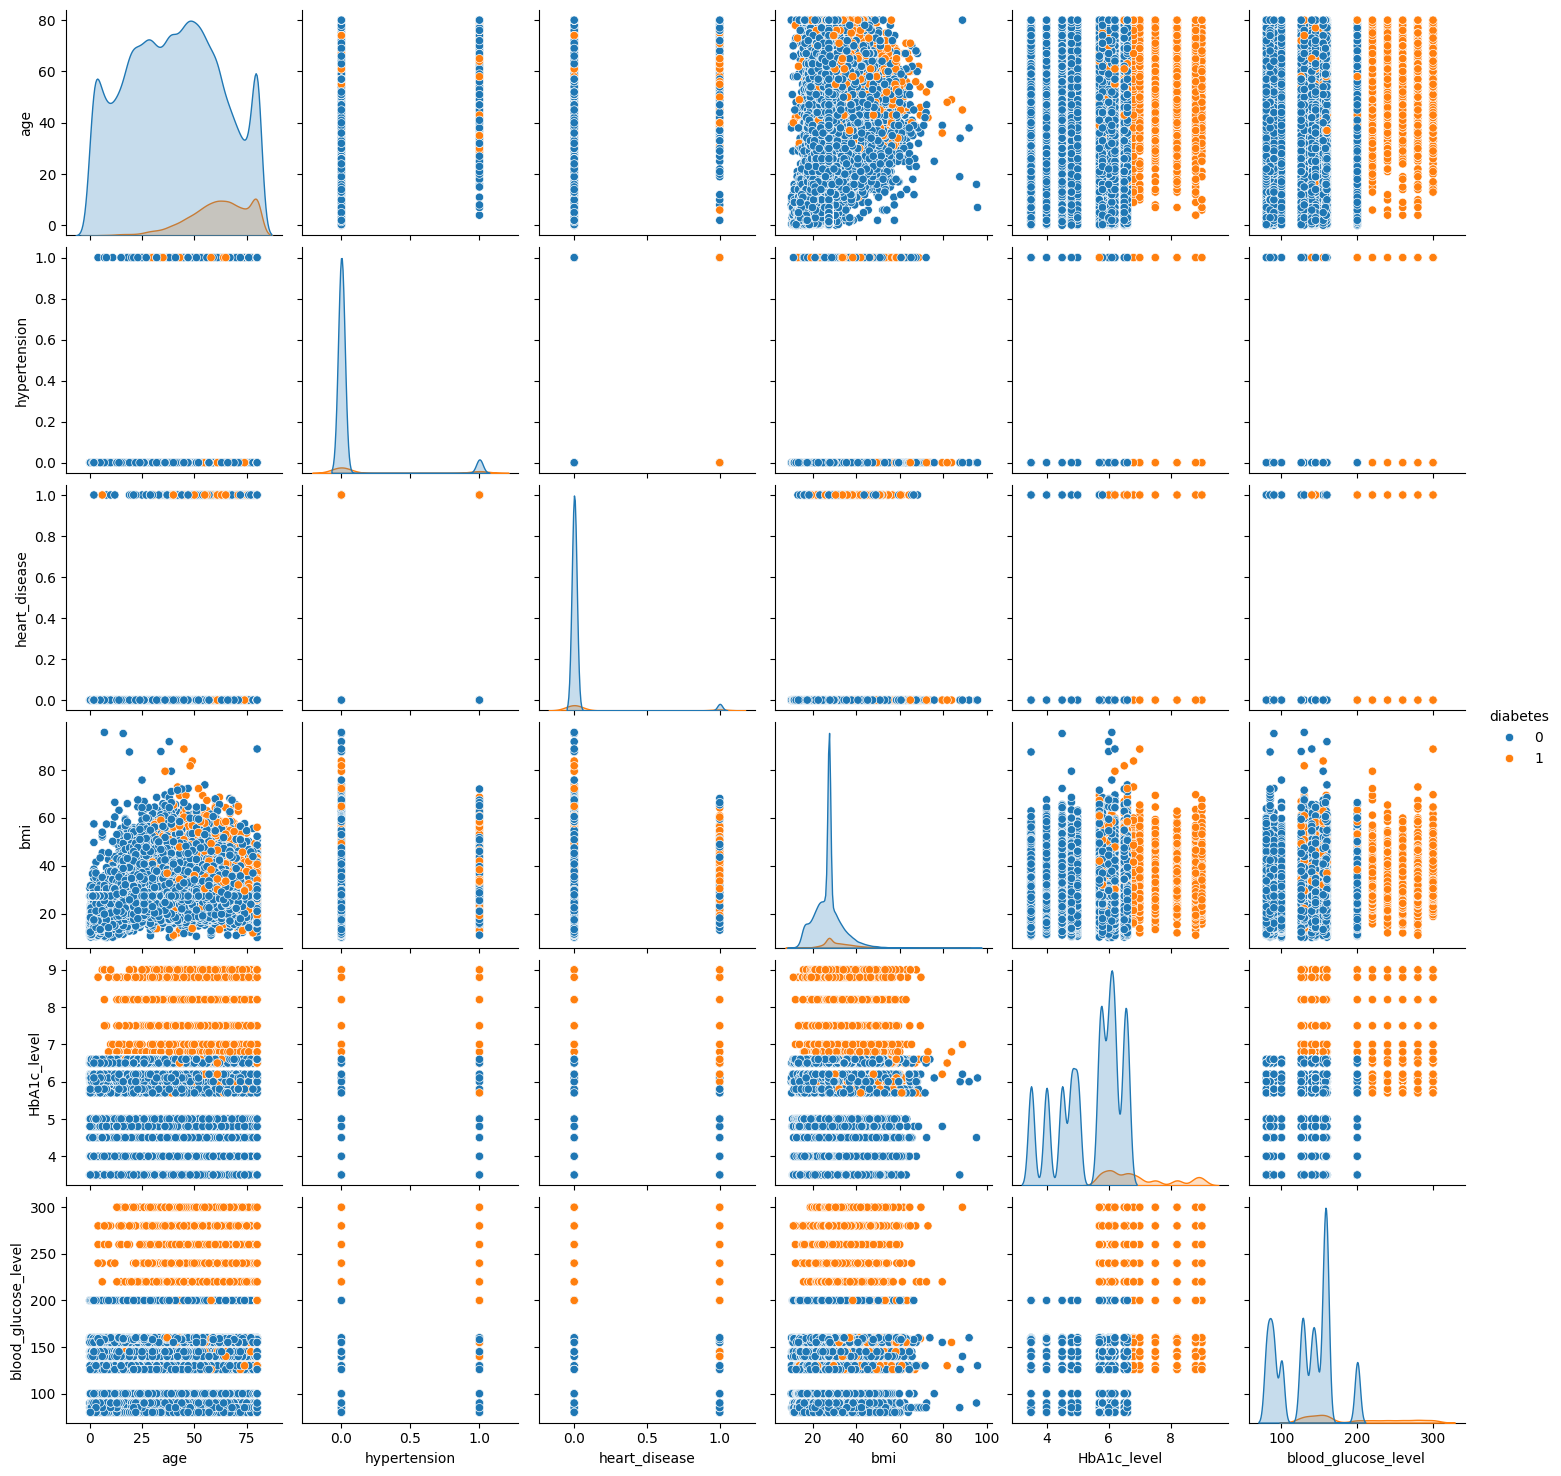

In [ ]:
pandas_df = df.select("*").toPandas()

# Create a pairplot using Seaborn
sns.pairplot(data=pandas_df, hue="diabetes")

# Show the plot
plt.show()

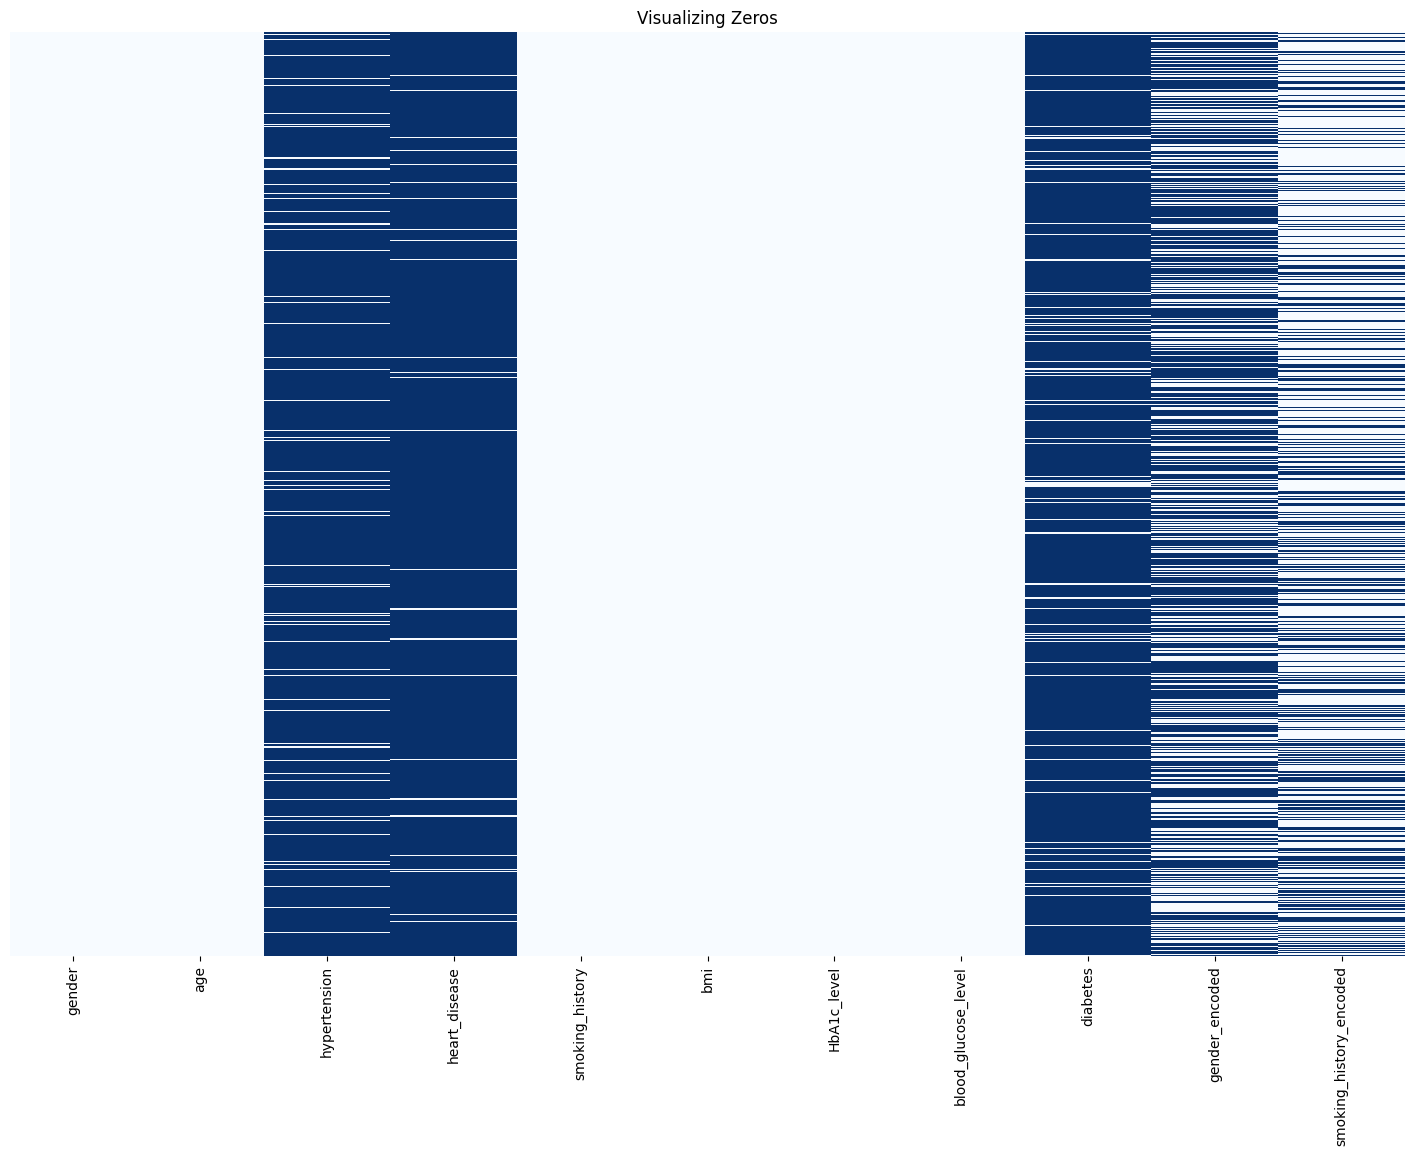

In [ ]:
plt.figure(figsize=(18,12))
plt.title("Visualizing Zeros")
sns.heatmap(pandas_df==0, cbar=False, cmap='Blues', yticklabels=False);
plt.show()

In [ ]:
df.filter((col("blood_glucose_level") != 0) & (col("hypertension") != 0) & (col("bmi") != 0))

df.show()

+------+----+------------+-------------+---------------+-----+-----------+-------------------+--------+
|gender| age|hypertension|heart_disease|smoking_history|  bmi|HbA1c_level|blood_glucose_level|diabetes|
+------+----+------------+-------------+---------------+-----+-----------+-------------------+--------+
|Female|80.0|           0|            1|          never|25.19|        6.6|                140|       0|
|Female|54.0|           0|            0|        No Info|27.32|        6.6|                 80|       0|
|  Male|28.0|           0|            0|          never|27.32|        5.7|                158|       0|
|Female|36.0|           0|            0|        current|23.45|        5.0|                155|       0|
|  Male|76.0|           1|            1|        current|20.14|        4.8|                155|       0|
|Female|20.0|           0|            0|          never|27.32|        6.6|                 85|       0|
|Female|44.0|           0|            0|          never|19.31|  

In [ ]:
df.groupBy('diabetes').mean().show()

+--------+------------------+-------------------+--------------------+-----------------+-----------------+------------------------+-------------+
|diabetes|          avg(age)|  avg(hypertension)|  avg(heart_disease)|         avg(bmi)| avg(HbA1c_level)|avg(blood_glucose_level)|avg(diabetes)|
+--------+------------------+-------------------+--------------------+-----------------+-----------------+------------------------+-------------+
|       1|60.946588235294115| 0.2456470588235294| 0.14905882352941177|31.98838235294212|6.934952941176317|      194.09470588235294|          1.0|
|       0| 40.11518688524602|0.05898360655737705|0.029234972677595627|26.88716349726619|5.396760655736246|      132.85246994535518|          0.0|
+--------+------------------+-------------------+--------------------+-----------------+-----------------+------------------------+-------------+



In [ ]:
df.groupBy('Age').mean().show()


+----+------------------+--------------------+--------------------+------------------+-----------------+------------------------+--------------------+
| Age|          avg(age)|   avg(hypertension)|  avg(heart_disease)|          avg(bmi)| avg(HbA1c_level)|avg(blood_glucose_level)|       avg(diabetes)|
+----+------------------+--------------------+--------------------+------------------+-----------------+------------------------+--------------------+
|67.0|              67.0|              0.1625| 0.11923076923076924| 29.24152884615376|5.692115384615397|      148.04615384615386| 0.22692307692307692|
| 8.0|               8.0|0.001141552511415525|0.001141552511415525|20.030970319634672| 5.37853881278539|       132.9052511415525|0.001141552511415525|
|70.0|              70.0| 0.15669205658324264| 0.11643090315560392|28.922219804134844|5.634929270946685|      145.28726877040262| 0.19912948857453755|
|69.0|              69.0| 0.18219461697722567| 0.12111801242236025| 29.07768115942026|5.747308

In [ ]:
df.select('gender', 'gender_index', 'smoking_history', 'smoking_history_index').show()


+------+------------+---------------+---------------------+
|gender|gender_index|smoking_history|smoking_history_index|
+------+------------+---------------+---------------------+
|Female|         0.0|          never|                  1.0|
|Female|         0.0|        No Info|                  0.0|
|  Male|         1.0|          never|                  1.0|
|Female|         0.0|        current|                  3.0|
|  Male|         1.0|        current|                  3.0|
|Female|         0.0|          never|                  1.0|
|Female|         0.0|          never|                  1.0|
|Female|         0.0|        No Info|                  0.0|
|  Male|         1.0|          never|                  1.0|
|Female|         0.0|          never|                  1.0|
|Female|         0.0|          never|                  1.0|
|Female|         0.0|         former|                  2.0|
|Female|         0.0|         former|                  2.0|
|Female|         0.0|          never|   

In [ ]:
from pyspark.sql.functions import col, count, when

# Kiểm tra lại giá trị thiếu trong tất cả các cột
missing_data = df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns])
missing_data.show()


+------+---+------------+-------------+---------------+---+-----------+-------------------+--------+------------+---------------------+
|gender|age|hypertension|heart_disease|smoking_history|bmi|HbA1c_level|blood_glucose_level|diabetes|gender_index|smoking_history_index|
+------+---+------------+-------------+---------------+---+-----------+-------------------+--------+------------+---------------------+
|     0|  0|           0|            0|              0|  0|          0|                  0|       0|           0|                    0|
+------+---+------------+-------------+---------------+---+-----------+-------------------+--------+------------+---------------------+



<h2> <b> So sánh và đánh giá các mô hình </b></h2>

In [ ]:
# Khởi tạo các mô hình
lr = LogisticRegression(featuresCol='features', labelCol='diabetes')
rf = RandomForestClassifier(featuresCol='features', labelCol='diabetes', numTrees=100)
gbt = GBTClassifier(featuresCol='features', labelCol='diabetes', maxIter=10)

# Huấn luyện các mô hình
lr_model = lr.fit(train_data)
rf_model = rf.fit(train_data)
gbt_model = gbt.fit(train_data)

# Tạo bộ đánh giá mô hình
evaluator = BinaryClassificationEvaluator(labelCol='diabetes', rawPredictionCol='prediction', metricName='areaUnderROC')

# Dự đoán trên tập kiểm tra và tính toán AUC
lr_predictions = lr_model.transform(test_data)
rf_predictions = rf_model.transform(test_data)
gbt_predictions = gbt_model.transform(test_data)

lr_auc = evaluator.evaluate(lr_predictions)
rf_auc = evaluator.evaluate(rf_predictions)
gbt_auc = evaluator.evaluate(gbt_predictions)

print(f"AUC của Logistic Regression: {lr_auc}")
print(f"AUC của Random Forest: {rf_auc}")
print(f"AUC của Gradient Boosting Trees: {gbt_auc}")

# Chuyển đổi dữ liệu Spark DataFrame sang Pandas DataFrame
lr_pd = lr_predictions.select("diabetes", "prediction").toPandas()
rf_pd = rf_predictions.select("diabetes", "prediction").toPandas()
gbt_pd = gbt_predictions.select("diabetes", "prediction").toPandas()


AUC của Logistic Regression: 0.8118794572131047
AUC của Random Forest: 0.8395610913404508
AUC của Gradient Boosting Trees: 0.8395610913404508


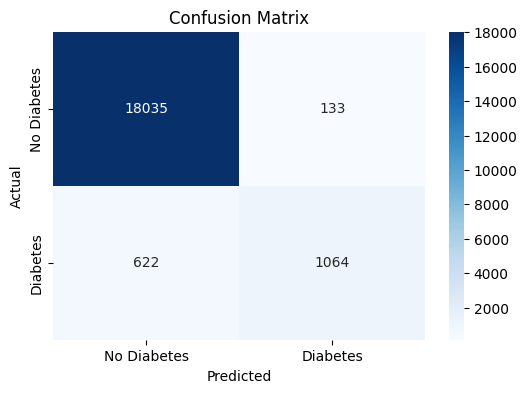

In [ ]:
# Dự báo trên tập kiểm tra (test set)
predictions = lr_model.transform(test_data)

# Lấy nhãn thực tế và nhãn dự đoán từ DataFrame
y_true = predictions.select("diabetes").rdd.flatMap(lambda x: x).collect()
y_pred = predictions.select("prediction").rdd.flatMap(lambda x: x).collect()

# Tính toán confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)

# Vẽ Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=["No Diabetes", "Diabetes"], yticklabels=["No Diabetes", "Diabetes"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

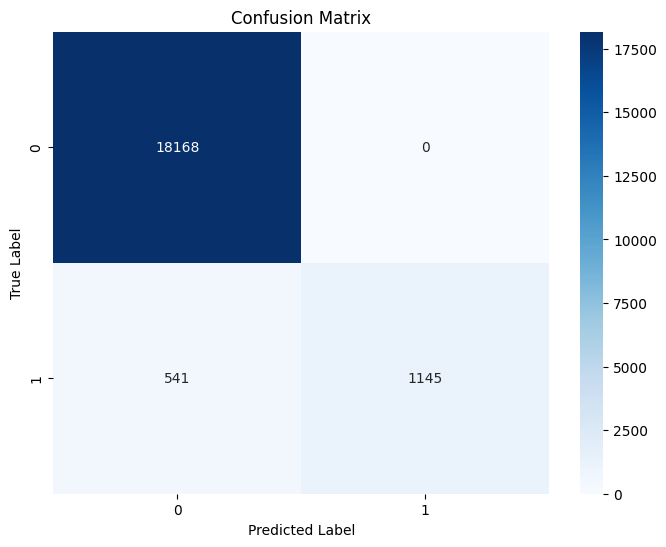

In [ ]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from sklearn.metrics import confusion_matrix

# Dự đoán nhãn
y_true = gbt_predictions.select("diabetes").collect()
y_pred = gbt_predictions.select("prediction").collect()

# Tạo ma trận nhầm lẫn
cm = confusion_matrix(y_true, y_pred)

# Vẽ ma trận nhầm lẫn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


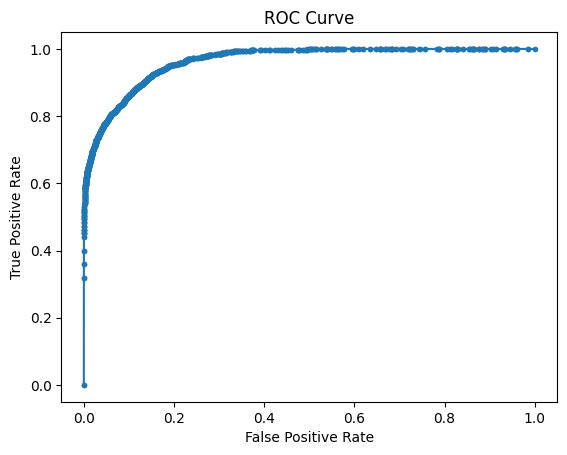

In [ ]:
# Vẽ biểu đồ ROC
from sklearn.metrics import roc_curve
roc_data = predictions.select("diabetes", "probability").rdd.map(lambda row: (row["probability"][1], row["diabetes"])).collect()
fpr, tpr, _ = roc_curve([x[1] for x in roc_data], [x[0] for x in roc_data])
plt.plot(fpr, tpr, marker='.')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

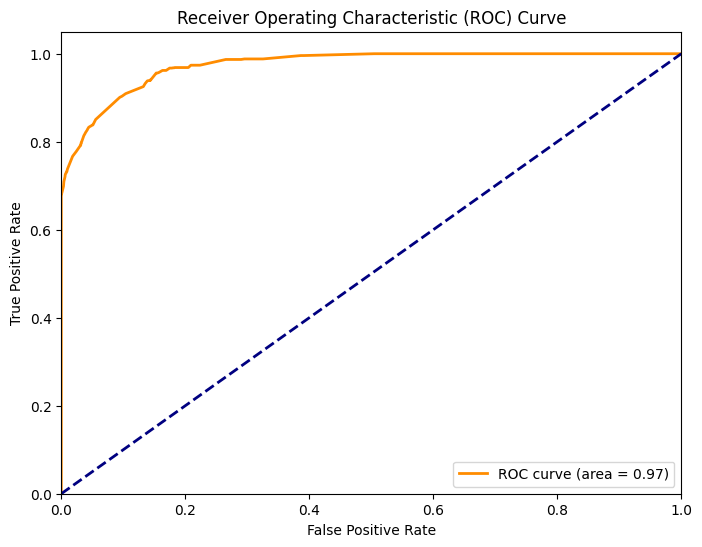

In [ ]:
from sklearn.metrics import roc_curve, auc
# Tính toán xác suất dự đoán
y_score = gbt_predictions.select("probability").collect()
y_true = gbt_predictions.select("diabetes").collect()

# Chuyển đổi xác suất và nhãn thành định dạng phù hợp
y_score = [prob.probability[1] for prob in y_score]  # Trích xuất giá trị xác suất từ DenseVector
y_true = [label.diabetes for label in y_true]  # Trích xuất nhãn thực tế

# Tính toán FPR và TPR
fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

# Vẽ đường cong ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


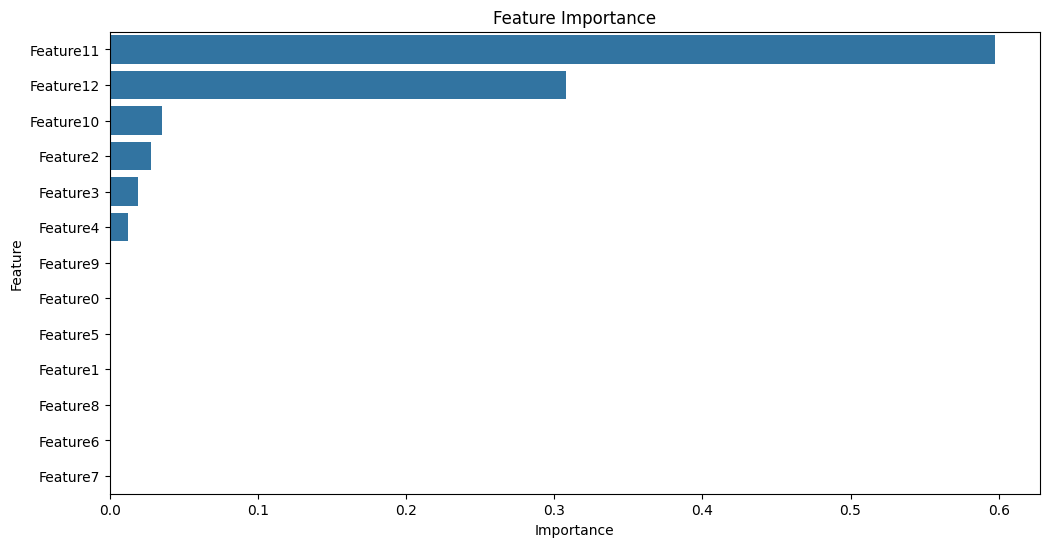

In [ ]:
# Lấy tầm quan trọng của đặc trưng từ mô hình
feature_importances = gbt_model.featureImportances.toArray()

# Tạo DataFrame cho tầm quan trọng của đặc trưng
features_df = pd.DataFrame({
    'Feature': ["Feature" + str(i) for i in range(len(feature_importances))],
    'Importance': feature_importances
})

# Sắp xếp theo tầm quan trọng
features_df = features_df.sort_values(by='Importance', ascending=False)

# Vẽ biểu đồ tầm quan trọng của đặc trưng
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=features_df)
plt.title('Feature Importance')
plt.show()


In [ ]:
from pyspark.ml.classification import GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.sql import SparkSession

if 'gender_index' not in df.columns:
    indexer_gender = StringIndexer(inputCol="gender", outputCol="gender_index")
    df = indexer_gender.fit(df).transform(df)

if 'smoking_history_index' not in df.columns:
    indexer_smoking = StringIndexer(inputCol="smoking_history", outputCol="smoking_history_index")
    df = indexer_smoking.fit(df).transform(df)

# Tạo feature vector
feature_columns = ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
                   'blood_glucose_level', 'gender_index', 'smoking_history_index']

assembler = VectorAssembler(inputCols=feature_columns, outputCol="features")
df_with_features = assembler.transform(df)

# Chia dữ liệu thành tập huấn luyện và kiểm tra
train_data, test_data = df_with_features.randomSplit([0.8, 0.2], seed=42)

# Khởi tạo mô hình GBT
gbt = GBTClassifier(labelCol='diabetes', featuresCol='features', seed=42)

# Tinh chỉnh siêu tham số
paramGrid = ParamGridBuilder() \
    .addGrid(gbt.maxDepth, [3, 5]) \
    .addGrid(gbt.maxIter, [50, 100]) \
    .build()

crossval = CrossValidator(estimator=gbt,
                          estimatorParamMaps=paramGrid,
                          evaluator=BinaryClassificationEvaluator(labelCol='diabetes'),
                          numFolds=5)

# Huấn luyện mô hình với cross-validation
cvModel = crossval.fit(train_data)

# Đánh giá mô hình trên tập kiểm tra
predictions = cvModel.transform(test_data)
evaluator = BinaryClassificationEvaluator(labelCol='diabetes')
auc = evaluator.evaluate(predictions)
print(f"AUC of the GBT model: {auc}")

# Hiển thị các siêu tham số tốt nhất
bestModel = cvModel.bestModel
print(f"Best Model Params: maxDepth={bestModel._java_obj.getMaxDepth()}, maxIter={bestModel._java_obj.getMaxIter()}")


AUC of the GBT model: 0.977487033508944
Best Model Params: maxDepth=5, maxIter=100


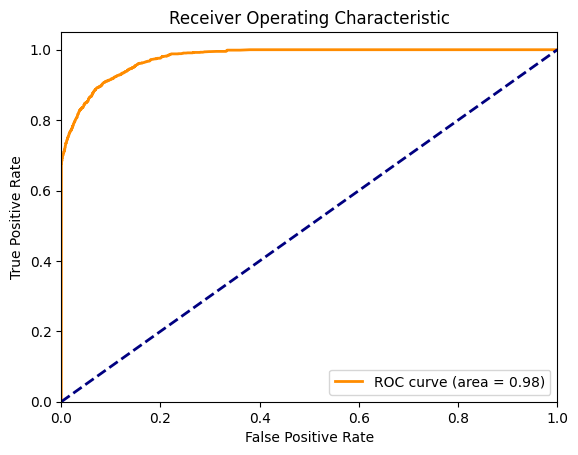

In [ ]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.functions import vector_to_array

# Lấy các điểm dự đoán từ mô hình
predictions = cvModel.transform(test_data)
evaluator = BinaryClassificationEvaluator(labelCol='diabetes')

# Tính toán AUC và điểm ROC
roc = evaluator.evaluate(predictions, {evaluator.metricName: "areaUnderROC"})

# Lấy các giá trị dự đoán và xác thực từ các điểm
predictions = predictions.withColumn("probability", vector_to_array("probability"))
prob_and_labels = predictions.select("probability", "diabetes").toPandas()

# Tính toán điểm ROC
from sklearn.metrics import roc_curve, auc

y_true = prob_and_labels["diabetes"]
y_scores = prob_and_labels["probability"].apply(lambda x: x[1])

fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# Vẽ biểu đồ ROC Curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


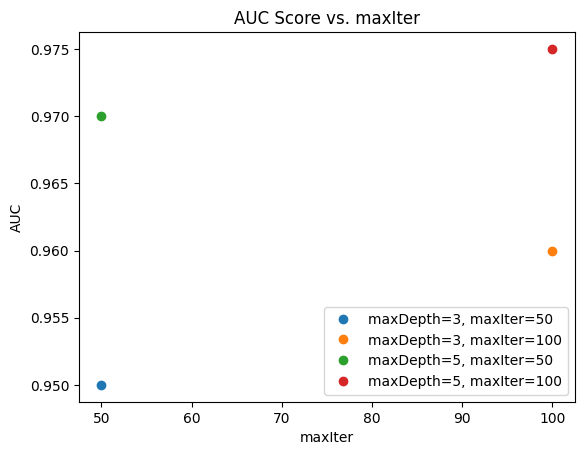

In [ ]:
# Ví dụ về các giá trị siêu tham số và độ chính xác tương ứng
params = {'maxDepth': [3, 5], 'maxIter': [50, 100]}
param_grid = [(d, i) for d in params['maxDepth'] for i in params['maxIter']]

# Giả sử bạn đã có các điểm số AUC cho từng cặp siêu tham số
# Thay thế danh sách scores bằng giá trị thực từ cross-validation
scores = [0.95, 0.96, 0.97, 0.975]  # Ví dụ, có 4 điểm số tương ứng

# Vẽ biểu đồ
plt.figure()
for i, (depth, iter) in enumerate(param_grid):
    plt.plot(iter, scores[i], 'o', label=f"maxDepth={depth}, maxIter={iter}")

plt.xlabel('maxIter')
plt.ylabel('AUC')
plt.title('AUC Score vs. maxIter')
plt.legend()
plt.show()


<h2> <b> Ứng dụng thuật toán K-mean trong phân tích bệnh tiểu đường </b> </h2>

In [ ]:
df.printSchema()  # In ra cấu trúc của DataFrame để kiểm tra tên cột


root
 |-- gender: string (nullable = true)
 |-- age: double (nullable = true)
 |-- hypertension: integer (nullable = true)
 |-- heart_disease: integer (nullable = true)
 |-- smoking_history: string (nullable = true)
 |-- bmi: double (nullable = true)
 |-- HbA1c_level: double (nullable = true)
 |-- blood_glucose_level: integer (nullable = true)
 |-- diabetes: integer (nullable = true)



In [ ]:
# Chuyển đổi các cột chuỗi thành số nếu cần
indexer_gender = StringIndexer(inputCol="gender", outputCol="gender_index")
indexer_smoking = StringIndexer(inputCol="smoking_history", outputCol="smoking_history_index")

df = indexer_gender.fit(df).transform(df)
df = indexer_smoking.fit(df).transform(df)

# Xác định các cột đặc trưng để tạo feature vector
feature_columns = ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
                   'blood_glucose_level', 'gender_index', 'smoking_history_index']

# Tạo feature vector
assembler = VectorAssembler(inputCols=feature_columns, outputCol="features")
df_with_features = assembler.transform(df)

# Áp dụng KMeans clustering
kmeans = KMeans(k=3, featuresCol="features", seed=1)  # số lượng cluster (k) có thể điều chỉnh
model = kmeans.fit(df_with_features)
df_with_clusters = model.transform(df_with_features)

# Hiển thị dữ liệu với nhãn cụm và các cột gốc
df_with_clusters.select('gender', 'age', 'hypertension', 'heart_disease',
                        'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'prediction').show()


+------+----+------------+-------------+---------------+-----+-----------+-------------------+----------+
|gender| age|hypertension|heart_disease|smoking_history|  bmi|HbA1c_level|blood_glucose_level|prediction|
+------+----+------------+-------------+---------------+-----+-----------+-------------------+----------+
|Female|80.0|           0|            1|          never|25.19|        6.6|                140|         2|
|Female|54.0|           0|            0|        No Info|27.32|        6.6|                 80|         1|
|  Male|28.0|           0|            0|          never|27.32|        5.7|                158|         2|
|Female|36.0|           0|            0|        current|23.45|        5.0|                155|         2|
|  Male|76.0|           1|            1|        current|20.14|        4.8|                155|         2|
|Female|20.0|           0|            0|          never|27.32|        6.6|                 85|         1|
|Female|44.0|           0|            0|      

In [ ]:
# Xác định các cột đặc trưng
feature_columns = ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
                   'blood_glucose_level', 'gender_index', 'smoking_history_index']

# Tạo feature vector
assembler = VectorAssembler(inputCols=feature_columns, outputCol="features")
df_with_features = assembler.transform(df)

# Áp dụng KMeans clustering
kmeans = KMeans(k=3, featuresCol="features", seed=1)  # số lượng cluster (k) có thể điều chỉnh
model = kmeans.fit(df_with_features)
df_with_clusters = model.transform(df_with_features)

# Nhóm các điểm dữ liệu theo cluster và đếm số lượng điểm trong mỗi cluster
df_with_clusters.groupBy('prediction').count().show()


+----------+-----+
|prediction|count|
+----------+-----+
|         1|28144|
|         2|60979|
|         0|10877|
+----------+-----+



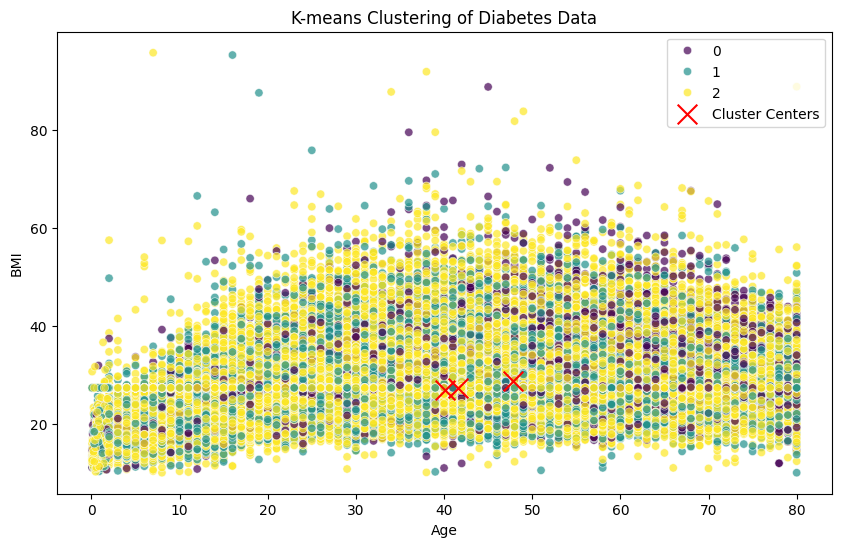

In [ ]:
# Chuyển đổi kết quả từ Spark DataFrame sang Pandas DataFrame
pandas_df = df_with_clusters.toPandas()

# Vẽ biểu đồ scatter plot để trực quan hóa các cụm (sử dụng hai đặc trưng đầu tiên)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=pandas_df, x='age', y='bmi', hue='prediction', palette='viridis', alpha=0.7)
plt.scatter(
    [center[0] for center in model.clusterCenters()],
    [center[3] for center in model.clusterCenters()],
    c='red', marker='x', s=200, label='Cluster Centers'
)
plt.title('K-means Clustering of Diabetes Data')
plt.xlabel('Age')
plt.ylabel('BMI')
plt.legend()
plt.show()
